In [1]:
import warnings

import networkx as nx
import scanpy as sc

warnings.filterwarnings("ignore")

In [7]:
# Load pbmc3k dataset
adata = sc.datasets.pbmc3k_processed()
# sc.read_h5ad("/Users/vladimir.shitov/Documents/science/PhD/data/processed_PBMC3k.h5ad")
print(f"Dataset shape: {adata.shape}")
print(f"KNN graph has {adata.uns['neighbors']['params']['n_neighbors']} neighbors")

100%|██████████| 23.5M/23.5M [00:02<00:00, 10.3MB/s]


Dataset shape: (2638, 1838)
KNN graph has [10] neighbors


In [8]:
import numpy as np

from patpy.tl.sample_representation import DiffusionEarthMoverDistance

adata.obs["sample"] = np.random.choice(["a", "b", "c"], size=adata.n_obs)

method = DiffusionEarthMoverDistance(sample_key="sample", cell_group_key="leiden")
method.prepare_anndata(adata)
method.calculate_distance_matrix()

array([[0.        , 0.01308025, 0.01978916],
       [0.01308025, 0.        , 0.01082102],
       [0.01978916, 0.01082102, 0.        ]])

In [10]:
adata.obs["louvain"]

index
AAACATACAACCAC-1        CD4 T cells
AAACATTGAGCTAC-1            B cells
AAACATTGATCAGC-1        CD4 T cells
AAACCGTGCTTCCG-1    CD14+ Monocytes
AAACCGTGTATGCG-1           NK cells
                         ...       
TTTCGAACTCTCAT-1    CD14+ Monocytes
TTTCTACTGAGGCA-1            B cells
TTTCTACTTCCTCG-1            B cells
TTTGCATGAGAGGC-1            B cells
TTTGCATGCCTCAC-1        CD4 T cells
Name: louvain, Length: 2638, dtype: category
Categories (8, object): ['CD4 T cells', 'CD14+ Monocytes', 'B cells', 'CD8 T cells', 'NK cells', 'FCGR3A+ Monocytes', 'Dendritic cells', 'Megakaryocytes']

In [6]:
method.calculate_distance_matrix()

array([[0.        , 0.01606399, 0.006478  ],
       [0.01606399, 0.        , 0.01105361],
       [0.006478  , 0.01105361, 0.        ]])

In [4]:
# Convert connectivities to NetworkX graph
G = nx.from_scipy_sparse_array(adata.obsp["connectivities"])
print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Calculate average path length
if nx.is_connected(G):
    avg_path_length = nx.average_shortest_path_length(G)
    print(f"Average shortest path length: {avg_path_length:.4f}")
else:
    largest_cc = max(nx.connected_components(G), key=len)
    G_largest = G.subgraph(largest_cc).copy()
    print(f"Graph has {len(list(nx.connected_components(G)))} components")
    print(f"Largest: {G_largest.number_of_nodes()} nodes ({100 * len(largest_cc) / G.number_of_nodes():.1f}%)")
    avg_path_length = nx.average_shortest_path_length(G_largest)
    print(f"Average shortest path length: {avg_path_length:.4f}")

Graph: 2638 nodes, 20976 edges
Average shortest path length: 4.3264


In [5]:
import numpy as np

# Get average path length for each node
avg_path_per_node = []
for node in G.nodes():
    path_lengths = nx.single_source_shortest_path_length(G, node)
    # Exclude self (distance 0)
    avg = np.mean([l for n, l in path_lengths.items() if n != node])
    avg_path_per_node.append(avg)

avg_path_per_node = np.array(avg_path_per_node)

# Add to adata
adata.obs["avg_path_length"] = avg_path_per_node

In [8]:
adata

AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'avg_path_length'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [19]:
adata.obs["n_neighbors"] = (adata.obsp["connectivities"] > 0).sum(axis=1)
adata.obs["log_n_neighbors"] = np.log1p(adata.obs["n_neighbors"])

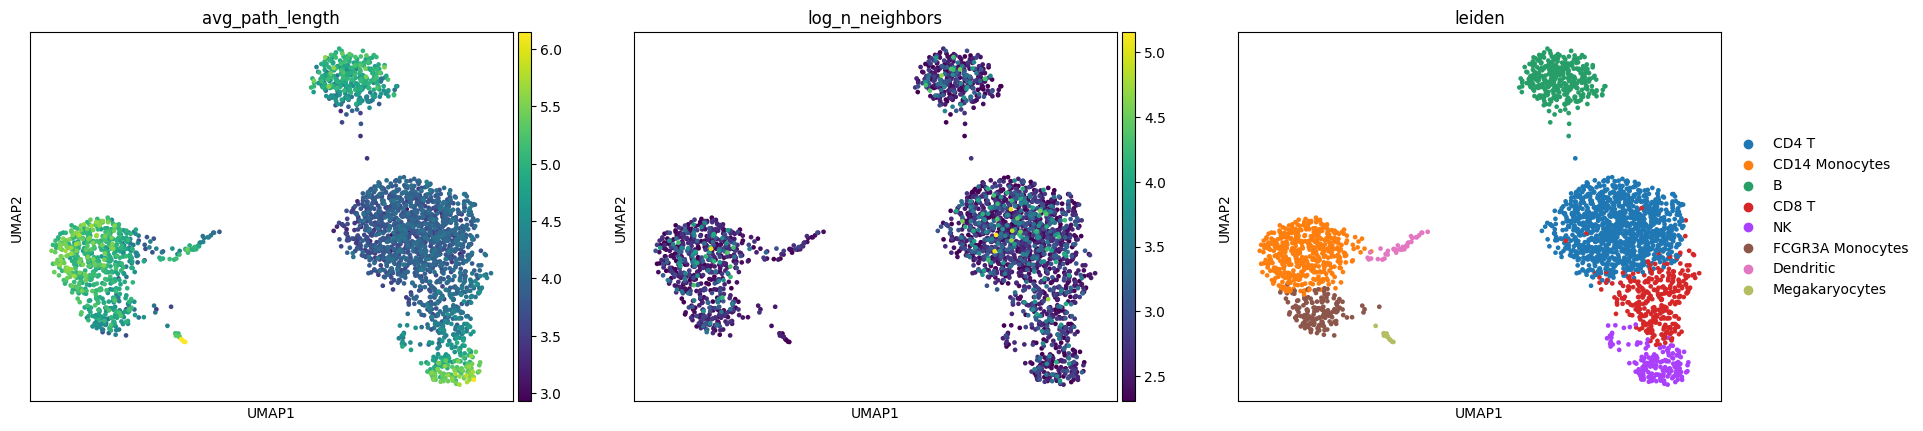

In [21]:
# Visualize on UMAP
sc.pl.umap(
    adata,
    color=[
        "avg_path_length",
        "log_n_neighbors",
        "leiden",
    ],
)

matrix([[ 9],
        [11],
        [11],
        ...,
        [18],
        [10],
        [11]])

In [ ]:
ф